# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
from itertools import product

# Loading and Saving
from moments.bloch import (compute_bipartite_region_upper, compute_bipartite_region_ent, compute_bipartite_region_lower)
from moments.ent_meas import compute_negativity
from moments.saving import get_experiment_paths, DATA_RAW

_, plots_dir = get_experiment_paths(__vsc_ipynb_file__)

# Configurations

In [2]:
print(plt.rcParams.keys())

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'b

In [3]:
plt.style.use('default')
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    #'figure.figsize': (7, 5),  # inches
    #'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.linewidth': 0.5,
    #0.8,
    'axes.edgecolor': 'black',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.fancybox': True,
    'legend.fontsize': 20,
})

# Two qubits

In [4]:
data_dir = DATA_RAW / "two_qubits" / "sym_plane"
ent_num = np.load(data_dir / "trace_norm_exact.npz")

ent_max_sym = 2 * compute_negativity(trace_norm_pt=ent_num["max"])
ent_min_sym = 2 * compute_negativity(trace_norm_pt=ent_num["min"])

data_dir = DATA_RAW / "two_qubits" / "xz_plane"
ent_num = np.load(data_dir / "trace_norm_exact.npz")

ent_max_xz = 2 * compute_negativity(trace_norm_pt=ent_num["max"])
ent_min_xz = 2 * compute_negativity(trace_norm_pt=ent_num["min"])

DN_sym = np.maximum(0, ent_max_sym - ent_min_sym)
DN_xz = np.maximum(0, ent_max_xz - ent_min_xz)
DN_vmax = max(np.nanmax(DN_sym), np.nanmax(DN_xz))

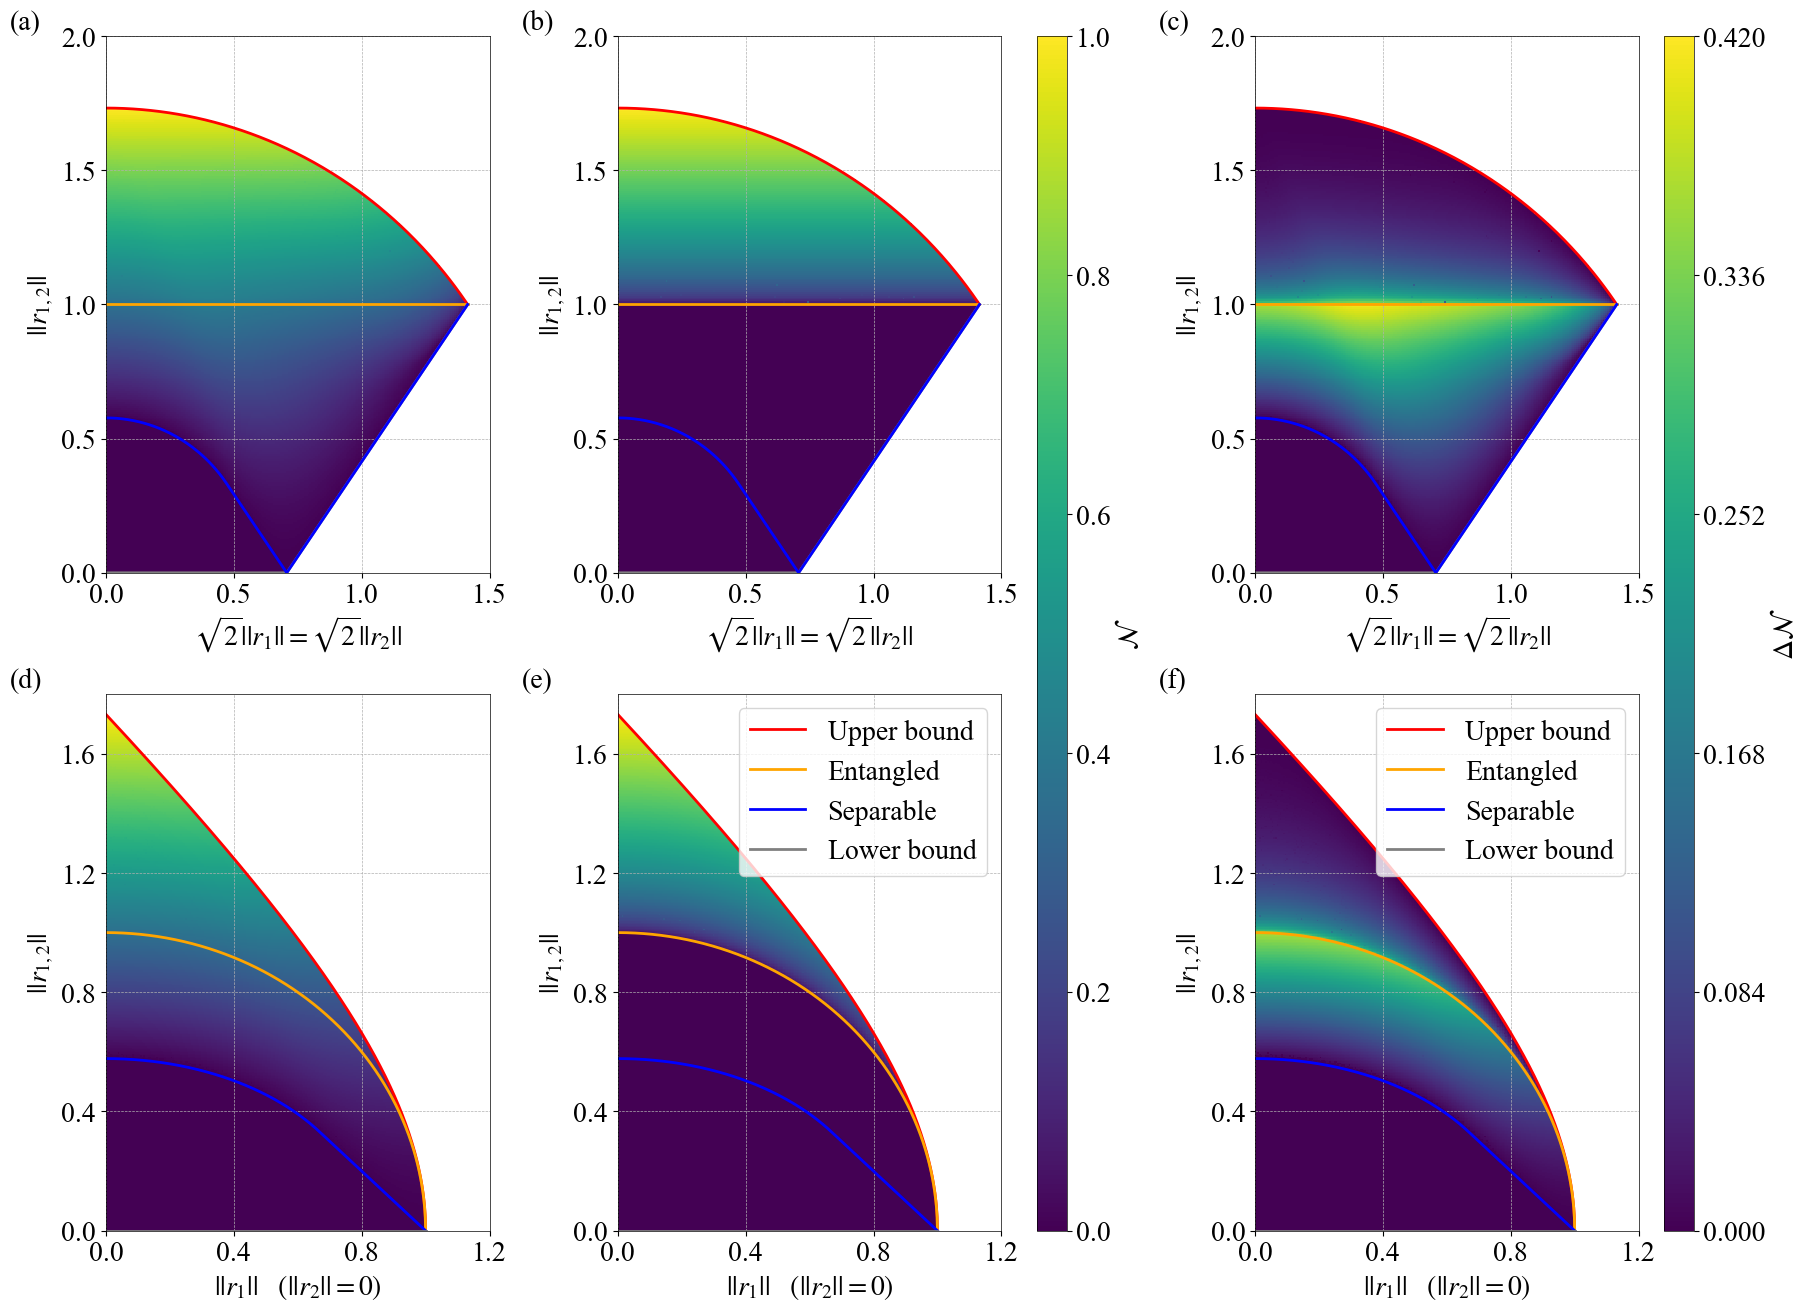

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(18, 13), constrained_layout=True)

Dt, Dz = ent_max_sym.shape
t = np.linspace(0, np.sqrt(2), Dt)
x = t / np.sqrt(2)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mesh0 = ax[0, 0].pcolormesh(np.sqrt(2) * X, Z, ent_max_sym, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[0, 1].pcolormesh(np.sqrt(2) * X, Z, ent_min_sym, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh2 = ax[0, 2].pcolormesh(np.sqrt(2) * X, Z, DN_sym, shading='auto', cmap='viridis', vmin=0, vmax=0.42)

z_upper = compute_bipartite_region_upper(2, x, x)
z_ent = compute_bipartite_region_ent(2, x, x)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_lower = compute_bipartite_region_lower([2, 2], x, x)

for i in range(3):
    ax[0, i].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$", xlim = (0, 1.5), ylim = (0, 2),
                 xticks=np.arange(0, 1.6, 0.5), yticks=np.arange(0, 2.1, 0.5))
    ax[0, i].plot(t, z_upper, 'red', linewidth=2, label='Upper bound')
    ax[0, i].plot(t, z_ent, 'orange', linewidth=2, label='Entangled')
    ax[0, i].plot(t, z_lower, 'grey', linewidth=2, label='Lower bound')
    ax[0, i].plot(t, z_sep, 'blue', linewidth=2, label='Separable')

Dx, Dz = ent_max_xz.shape
x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mesh3 = ax[1, 0].pcolormesh(X, Z, ent_max_xz, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh4 = ax[1, 1].pcolormesh(X, Z, ent_min_xz, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh5 = ax[1, 2].pcolormesh(X, Z, DN_xz, shading='auto', cmap='viridis', vmin=0, vmax=0.42)

x = np.linspace(0, 1, 1000)
z_upper = compute_bipartite_region_upper(2, x, 0)
z_ent = compute_bipartite_region_ent(2, x, 0)
z_sep = np.piecewise(x, [x <= 2/3, x > 2/3], [lambda x: np.sqrt(1/6 * (2 - 3 * x**2)), lambda x: 1 - x])
z_lower = compute_bipartite_region_lower([2, 2], x, 0)

for i in range(3):
    ax[1, i].set(xlabel = r"$|| r_1 || \quad (|| r_2 || = 0)$", ylabel = r"$||r_{1, 2}||$", xlim = (0, 1.2), ylim = (0, 1.8),
                 xticks=np.arange(0, 1.3, 0.4), yticks=np.arange(0, 1.9, 0.4))
    ax[1, i].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
    ax[1, i].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
    ax[1, i].plot(x, z_sep, 'blue', linewidth=2, label='Separable')
    ax[1, i].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

cbar0 = fig.colorbar(mesh0, ax=ax[:, 0:2].ravel().tolist(), label=r'$\mathcal{N}$', pad=0.02, aspect=40, shrink=1)
cbar0.set_ticks(list(np.linspace(0, 1, 6)))

cbar1 = fig.colorbar(mesh5, ax=ax[:, 2].ravel().tolist(), label=r'$\Delta \mathcal{N}$', pad=0.02, aspect=40, shrink=1)
cbar1.set_ticks(list(np.linspace(0, 0.42, 6)))

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for i, j in product(range(2), range(3)):
    ax[i, j].grid(True)
    ax[i, j].text(-0.25, 1.05, labels[i * 3 + j], transform=ax[i, j].transAxes, va='top', ha='left')
ax[1, 2].legend(loc='upper right')
ax[1, 1].legend(loc='upper right')

plt.savefig(plots_dir / "qubit_entanglement.png")
plt.show()

# Three qubits

In [6]:
data_dir = DATA_RAW / "two_qutrits" / "sym_plane"
ent_num = np.load(data_dir / "trace_norm_exact.npz")

ent_max_sym = compute_negativity(trace_norm_pt=ent_num["max"])
ent_min_sym = compute_negativity(trace_norm_pt=ent_num["min"])

data_dir = DATA_RAW / "two_qutrits" / "xz_plane"
ent_num = np.load(data_dir / "trace_norm_exact.npz")

ent_max_xz = compute_negativity(trace_norm_pt=ent_num["max"])
ent_min_xz = compute_negativity(trace_norm_pt=ent_num["min"])

DN_sym = np.maximum(0, ent_max_sym - ent_min_sym)
DN_xz = np.maximum(0, ent_max_xz - ent_min_xz)
DN_vmax = max(np.nanmax(DN_sym), np.nanmax(DN_xz))

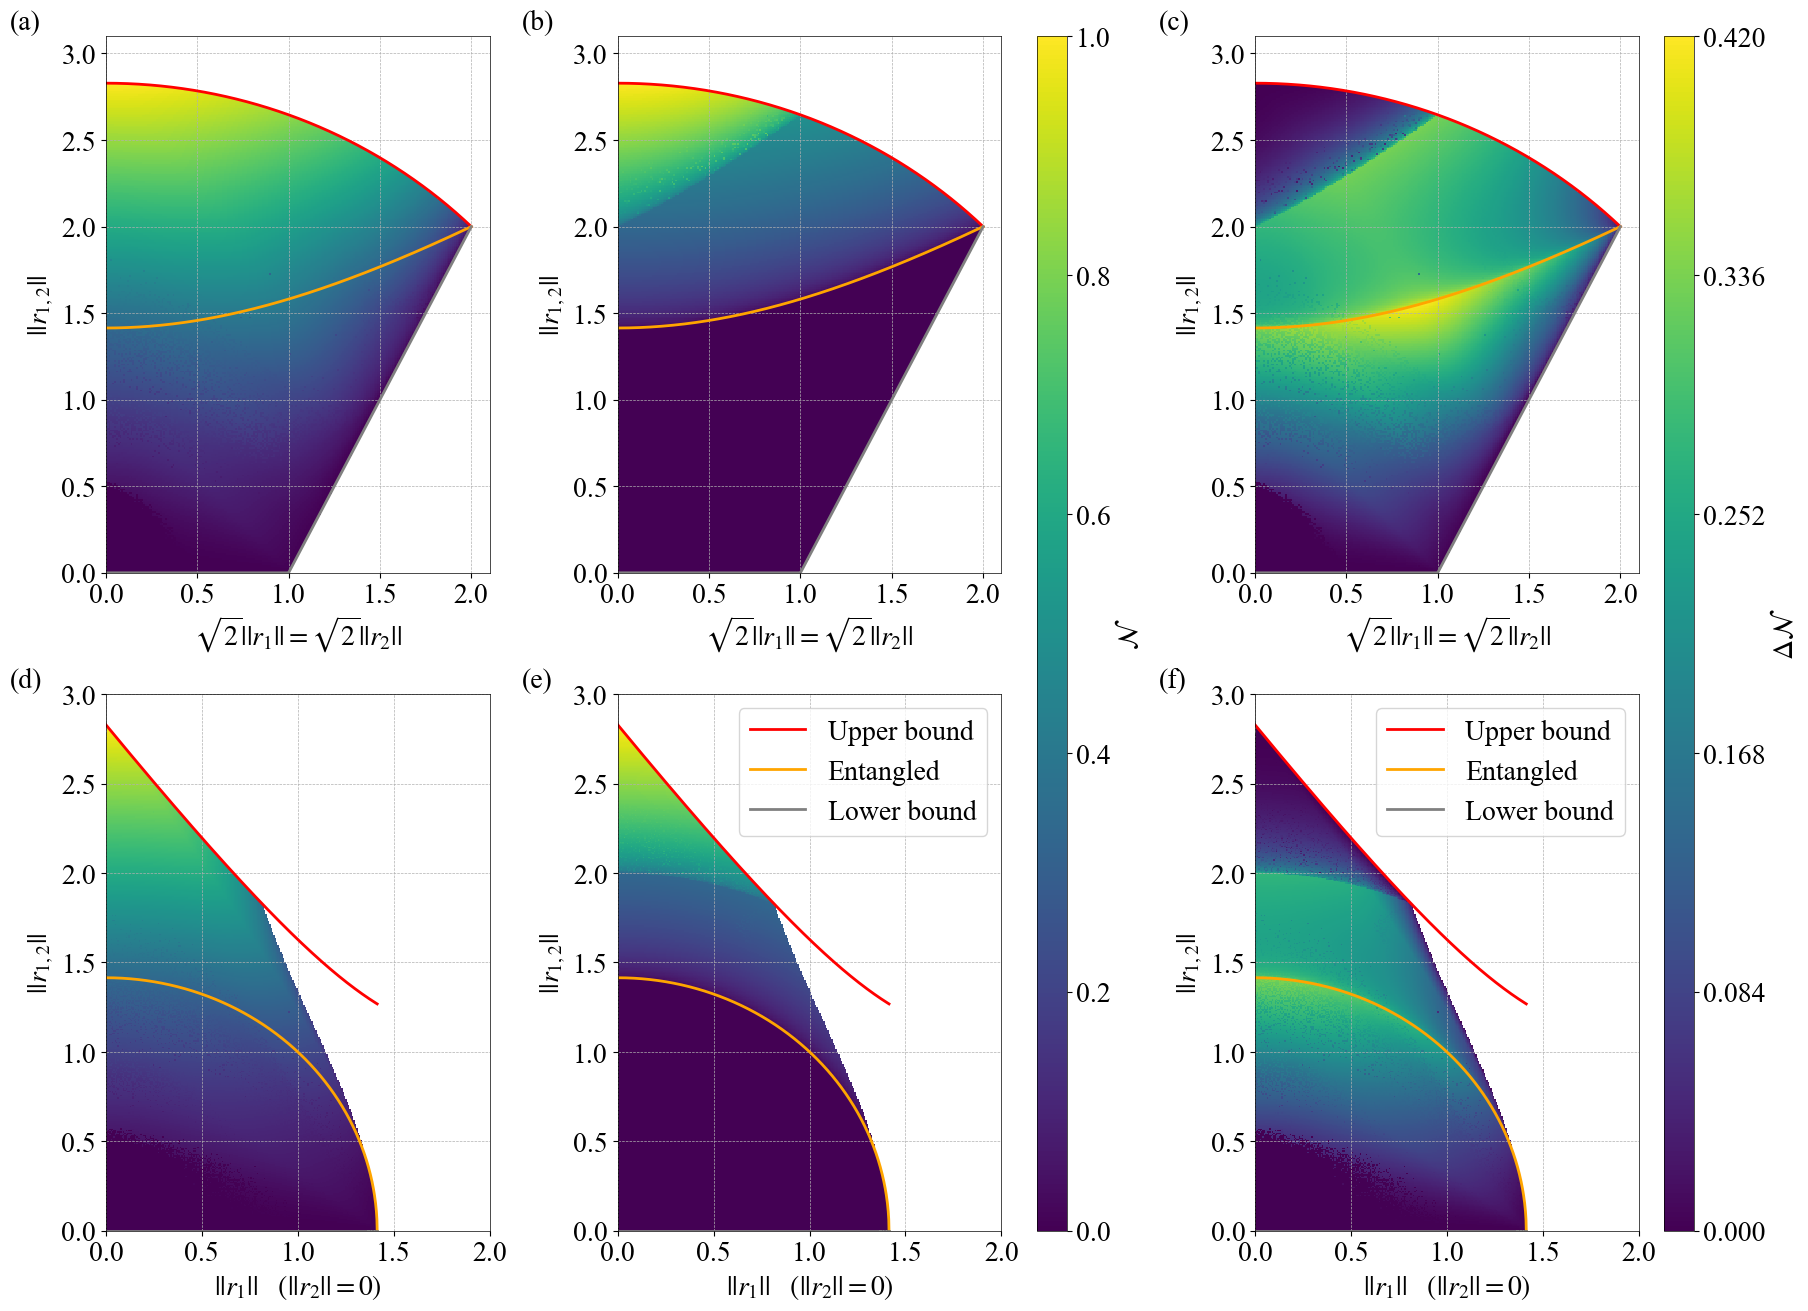

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(18, 13), constrained_layout=True)

Dt, Dz = ent_max_sym.shape
t = np.linspace(0, 2, Dt)
x = t / np.sqrt(2)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mesh0 = ax[0, 0].pcolormesh(np.sqrt(2) * X, Z, ent_max_sym, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[0, 1].pcolormesh(np.sqrt(2) * X, Z, ent_min_sym, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh2 = ax[0, 2].pcolormesh(np.sqrt(2) * X, Z, DN_sym, shading='auto', cmap='viridis', vmin=0, vmax=0.42)

t = np.linspace(0, 2, 1000)
x = t / np.sqrt(2)
z_upper = compute_bipartite_region_upper(3, x, x)
z_ent = compute_bipartite_region_ent(3, x, x)
z_lower = compute_bipartite_region_lower([3, 3], x, x)

for i in range(3):
    ax[0, i].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$", xlim = (0, 2.1), ylim = (0, 3.1),
                 xticks=np.arange(0, 2.1, 0.5), yticks=np.arange(0, 3.1, 0.5))
    ax[0, i].plot(t, z_upper, 'red', linewidth=2)
    ax[0, i].plot(t, z_ent, 'orange', linewidth=2)
    ax[0, i].plot(t, z_lower, 'grey', linewidth=2)

Dx, Dz = ent_max_xz.shape
x = np.linspace(0, np.sqrt(2), Dx)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mesh3 = ax[1, 0].pcolormesh(X, Z, ent_max_xz, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh4 = ax[1, 1].pcolormesh(X, Z, ent_min_xz, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh5 = ax[1, 2].pcolormesh(X, Z, DN_xz, shading='auto', cmap='viridis', vmin=0, vmax=0.42)

x = np.linspace(0, np.sqrt(2), 1000)
z_upper = compute_bipartite_region_upper(3, x, 0)
z_ent = compute_bipartite_region_ent(3, x, 0)
z_lower = compute_bipartite_region_lower([3, 3], x, 0)

for i in range(3):
    ax[1, i].set(xlabel = r"$|| r_1 || \quad (|| r_2 || = 0)$", ylabel = r"$||r_{1, 2}||$", xlim = (0, 2), ylim = (0, 3),
                 xticks=np.arange(0, 2.1, 0.5), yticks=np.arange(0, 3.1, 0.5))
    ax[1, i].plot(x, z_upper, 'red', linewidth=2, label='Upper bound')
    ax[1, i].plot(x, z_ent, 'orange', linewidth=2, label='Entangled')
    ax[1, i].plot(x, z_lower, 'grey', linewidth=2, label='Lower bound')

#cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label=r'$\mathcal{N}(\rho)$', pad=0.05, aspect=40, shrink=1)
cbar0 = fig.colorbar(mesh0, ax=ax[:, 0:2].ravel().tolist(), label=r'$\mathcal{N}$', pad=0.02, aspect=40, shrink=1)
cbar0.set_ticks(list(np.linspace(0, 1, 6)))

cbar1 = fig.colorbar(mesh5, ax=ax[:, 2].ravel().tolist(), label=r'$\Delta \mathcal{N}$', pad=0.02, aspect=40, shrink=1)
cbar1.set_ticks(list(np.linspace(0, 0.42, 6)))

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for i, j in product(range(2), range(3)):
    ax[i, j].grid(True)
    ax[i, j].text(-0.25, 1.05, labels[i * 3 + j], transform=ax[i, j].transAxes, va='top', ha='left')
ax[1, 2].legend(loc='upper right')
ax[1, 1].legend(loc='upper right')

plt.savefig(plots_dir / "qutrit_entanglement.png")
plt.show()